In [ ]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_5071.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_5031.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_314.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_2550.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_2234.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_3188.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_1324.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_1590.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_1363.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_1442.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_7272.png
/kaggle/inp

In [37]:
# Importation des bibliothèques principales
import os
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# Vérification de l'activation du GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("--- Statut de l'environnement ---")
print(f"PyTorch version : {torch.__version__}")
print(f"L'appareil utilisé pour les calculs est : {device}")

if device.type == 'cuda':
    print(f"Nom du GPU : {torch.cuda.get_device_name(0)}")
else:
    print("ATTENTION : Le GPU n'est pas activé. Les calculs seront très lents.")

--- Statut de l'environnement ---
PyTorch version : 2.10.0+cu128
L'appareil utilisé pour les calculs est : cuda
Nom du GPU : Tesla T4


In [38]:
import os

# 1. Définition du chemin principal vers le dataset
dataset_path = '/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD'

# 2. On définit les chemins vers les 3 sous-dossiers : 
# Training (pour apprendre), Development (pour valider pendant l'apprentissage), Evaluation (pour le test final)
train_dir = os.path.join(dataset_path, 'LCC_FASD_training')
val_dir = os.path.join(dataset_path, 'LCC_FASD_development')
test_dir = os.path.join(dataset_path, 'LCC_FASD_evaluation')

# 3. Petite fonction pratique pour compter le nombre d'images par classe (réel vs spoof)
def count_images(directory):
    if not os.path.exists(directory):
        return "Dossier introuvable (Vérifiez le chemin !)"
    
    counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

# 4. Affichage des résultats
print("--- Analyse du contenu du Dataset LCC FASD ---")
print(f"Dossier d'entraînement (Train) : {count_images(train_dir)}")
print(f"Dossier de validation (Dev) : {count_images(val_dir)}")
print(f"Dossier de test (Eval) : {count_images(test_dir)}")

--- Analyse du contenu du Dataset LCC FASD ---
Dossier d'entraînement (Train) : {'spoof': 7076, 'real': 1223}
Dossier de validation (Dev) : {'spoof': 2543, 'real': 405}
Dossier de test (Eval) : {'spoof': 7266, 'real': 314}


In [40]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt

print("--- Préparation du Data Pipeline ---")

# 1. Les "Transformations" : On met les images au format attendu par le Swin Transformer
# On ajoute une petite Data Augmentation (RandomHorizontalFlip) pour le train
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Retourne l'image aléatoirement comme un miroir
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet
])

transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Chargement des dossiers avec ImageFolder
train_dataset = ImageFolder(root=train_dir, transform=transform_train)
val_dataset = ImageFolder(root=val_dir, transform=transform_val_test)
test_dataset = ImageFolder(root=test_dir, transform=transform_val_test)

# 3. GESTION DU DÉSÉQUILIBRE (Le cœur de la stratégie)
# On calcule le poids de chaque classe (plus une classe est rare, plus son poids est fort)
class_counts = [1223, 7076] # [real, spoof] 
class_weights = [1.0 / count for count in class_counts]

# On attribue le poids correspondant à chaque image du dataset d'entraînement
sample_weights = [class_weights[label] for _, label in train_dataset]

# Le "Sampler" va utiliser ces poids pour piocher les images de façon équilibrée
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_dataset), replacement=True)

# 4. Création des DataLoaders (les camions de livraison d'images vers l'IA)
batch_size = 32 # On donne les images par paquets de 32 à l'IA
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Classes détectées par PyTorch : {train_dataset.classes}")
print(f"Nombre de paquets (batches) pour l'entraînement : {len(train_loader)}")
print("Le pipeline est prêt et équilibré !")

--- Préparation du Data Pipeline ---
Classes détectées par PyTorch : ['real', 'spoof']
Nombre de paquets (batches) pour l'entraînement : 260
Le pipeline est prêt et équilibré !


--- Inspection visuelle du Dataset ---


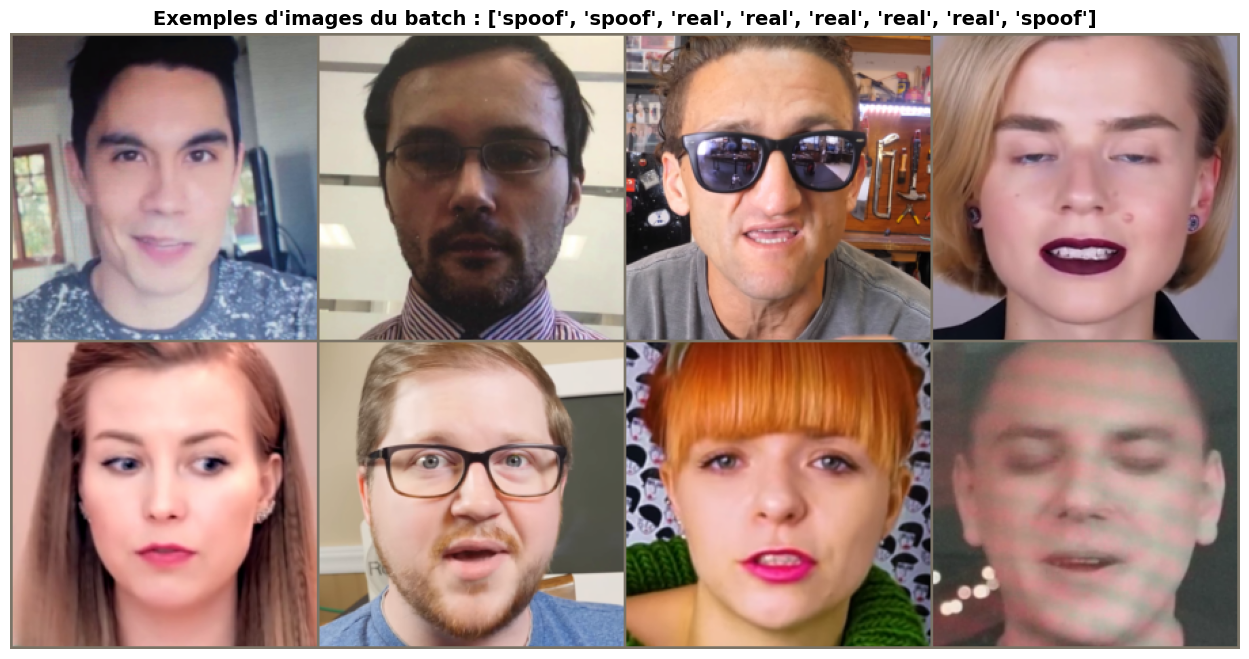

In [28]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

print("--- Inspection visuelle du Dataset ---")

# Fonction pour "dé-normaliser" et afficher les images correctement
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # On remet les couleurs d'origine (inverse de la normalisation ImageNet)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # S'assure que les valeurs des pixels restent entre 0 et 1
    
    plt.figure(figsize=(16, 8))
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# On demande à notre "train_loader" de nous livrer 1 seul paquet (batch) d'images
images, labels = next(iter(train_loader))
class_names = train_dataset.classes

# On prend seulement les 8 premières images du paquet pour que ce soit lisible
images_to_show = images[:8]
labels_to_show = labels[:8]

# On crée une grille avec ces 8 images
grid = torchvision.utils.make_grid(images_to_show, nrow=4)

# On prépare les titres (Real ou Spoof) pour chaque image
titres = [class_names[x] for x in labels_to_show]

# On affiche la grille !
imshow(grid, title=f"Exemples d'images du batch : {titres}")

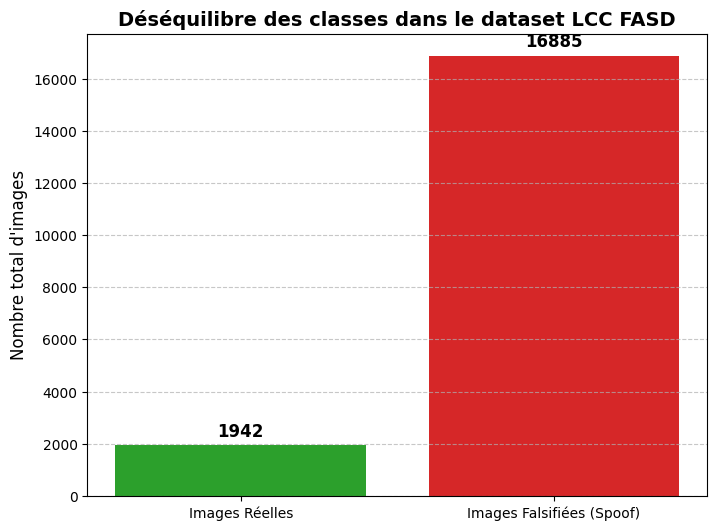

Graphique généré et sauvegardé sous le nom 'lcc_fasd_distribution.png' ! Vous pourrez le télécharger pour votre article.


In [29]:
import matplotlib.pyplot as plt


# Les données exactes de votre présentation LCC FASD
classes = ['Images Réelles', 'Images Falsifiées (Spoof)']
quantites = [1942, 16885] 

# Création du graphique
plt.figure(figsize=(8, 6))
# On utilise le vert pour les vraies images et le rouge pour les fausses,
# pour correspondre aux couleurs de votre diapositive "Workflow"
bars = plt.bar(classes, quantites, color=['#2ca02c', '#d62728'])

# Ajout des chiffres exacts au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 200, int(yval), 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# Esthétique du graphique (titres, légendes)
plt.title('Déséquilibre des classes dans le dataset LCC FASD', fontsize=14, fontweight='bold')
plt.ylabel('Nombre total d\'images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Cette ligne sauvegarde l'image directement dans l'espace Kaggle !
plt.savefig('lcc_fasd_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

print("Graphique généré et sauvegardé sous le nom 'lcc_fasd_distribution.png' ! Vous pourrez le télécharger pour votre article.")

Fine Tune 1 

In [30]:
!pip install timm # À exécuter dans une cellule Kaggle

import torch
import torch.nn as nn
import torch.optim as optim
import timm
from tqdm import tqdm # Pour la barre de progression
from sklearn.metrics import f1_score, precision_score

In [31]:
# 1. Chargement du modèle Swin Tiny (adapté pour 224x224)
# num_classes=2 car on a 'real' et 'spoof'
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=2)

# 2. STRATÉGIE 1 : Geler tous les paramètres
for param in model.parameters():
    param.requires_grad = False

# 3. Dégeler le dernier bloc (Stage 4) et la tête (Head)
# Dans Swin Tiny de timm, les stages sont dans model.layers
# layers[3] correspond au Stage 4
for param in model.layers[3].parameters():
    param.requires_grad = True

for param in model.head.parameters():
    param.requires_grad = True

model = model.to(device) # Envoyer au GPU Tesla T4

# Vérification : On compte les paramètres entraînables
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres entraînables pour Stratégie 1 : {trainable_params}")

Paramètres entraînables pour Stratégie 1 : 15368114


In [32]:
criterion = nn.CrossEntropyLoss()
# On ne passe à l'optimiseur QUE les paramètres dégelés
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    accuracy = 100. * sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)
    f1 = f1_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    
    return running_loss / len(loader), accuracy, f1, prec

In [37]:
num_epochs = 10
best_f1 = 0.0

for epoch in range(num_epochs):
    # 1. Entraînement
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # 2. Validation (CORRECTION ICI : model d'abord, puis val_loader)
    val_loss, val_acc, val_f1, val_prec = validate(model, val_loader, criterion, device)
    
    print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | F1: {val_f1:.4f}")
    
    # Sauvegarde du meilleur modèle
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'swin_strategy1_best.pth')
        print("=> Modèle sauvegardé !")

Validation: 100%|██████████| 93/93 [00:55<00:00,  1.67it/s]



--- Epoch 1/10 ---
Train Loss: 0.0219 | Train Acc: 99.31%
Val Loss: 0.0720 | Val Acc: 98.03% | F1: 0.9886
=> Modèle sauvegardé !


Validation: 100%|██████████| 93/93 [00:55<00:00,  1.67it/s]



--- Epoch 2/10 ---
Train Loss: 0.0150 | Train Acc: 99.57%
Val Loss: 0.1244 | Val Acc: 97.05% | F1: 0.9831


Validation: 100%|██████████| 93/93 [00:55<00:00,  1.68it/s]


...


--- Epoch 8/10 ---
Train Loss: 0.0092 | Train Acc: 99.72%
Val Loss: 0.1827 | Val Acc: 96.20% | F1: 0.9776


Validation: 100%|██████████| 93/93 [00:55<00:00,  1.68it/s]



--- Epoch 9/10 ---
Train Loss: 0.0035 | Train Acc: 99.89%
Val Loss: 0.1005 | Val Acc: 98.51% | F1: 0.9913


Validation: 100%|██████████| 93/93 [00:55<00:00,  1.68it/s]


--- Epoch 10/10 ---
Train Loss: 0.0010 | Train Acc: 99.98%
Val Loss: 0.1050 | Val Acc: 98.37% | F1: 0.9905


In [43]:
!pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 10.5 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: req

In [47]:
import torch
import torch.nn as nn
import timm
import torchattacks
from tqdm import tqdm

# 1. REDÉFINIR L'ARCHITECTURE (Pour être sûr)
def get_model(strategy, device):
    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=2)
    if strategy == "1_fine_tune":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layers[3].parameters(): # Stage 4
            param.requires_grad = True
        for param in model.head.parameters():
            param.requires_grad = True
    return model.to(device)

# 2. CONFIGURATION ET CHARGEMENT DU MODÈLE ENTRAÎNÉ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_test = get_model("1_fine_tune", device)

try:
    model_test.load_state_dict(torch.load('/kaggle/input/models/tahiralefechtali/mes-modeles-fasd/pytorch/default/1/swin_strategy1_best.pth'))
    model_test.eval()
    print("✅ Succès : Le meilleur modèle (Stratégie 1) a été chargé !")
except FileNotFoundError:
    print("❌ Erreur : Le fichier 'swin_strategy1_best.pth' est introuvable. Vérifie le nom !")

# 3. FONCTION D'ÉVALUATION DE LA ROBUSTESSE
def evaluate_robustness(model, loader, device):
    model.eval()
    
    # Paramètres d'attaque (standards pour la recherche)
    atk_fgsm = torchattacks.FGSM(model, eps=0.01)
    atk_pgd = torchattacks.PGD(model, eps=0.01, alpha=0.01, steps=10)

    correct_clean = 0
    correct_fgsm = 0
    correct_pgd = 0
    total = 0
    
    print("\n Lancement des attaques...")

    # On teste sur le test_loader
    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)
        total += labels.size(0)
        
        # Test Clean
        with torch.no_grad():
            outputs = model(images)
            _, pred_clean = outputs.max(1)
            correct_clean += pred_clean.eq(labels).sum().item()
        
        # Test FGSM
        adv_images_fgsm = atk_fgsm(images, labels)
        outputs_fgsm = model(adv_images_fgsm)
        _, pred_fgsm = outputs_fgsm.max(1)
        correct_fgsm += pred_fgsm.eq(labels).sum().item()
        
        # Test PGD
        adv_images_pgd = atk_pgd(images, labels)
        outputs_pgd = model(adv_images_pgd)
        _, pred_pgd = outputs_pgd.max(1)
        correct_pgd += pred_pgd.eq(labels).sum().item()

    # Affichage final
    print("\n" + "="*45)
    print(f"📊 RÉSULTATS ROBUSTESSE - STRATÉGIE 1")
    print("="*45)
    print(f"✅ Accuracy sur images normales : {100. * correct_clean / total:.2f}%")
    print(f"⚠️ Accuracy sous attaque FGSM   : {100. * correct_fgsm / total:.2f}%")
    print(f"🔥 Accuracy sous attaque PGD    : {100. * correct_pgd / total:.2f}%")
    print("="*45)

# 4. LANCEMENT DU TEST
evaluate_robustness(model_test, test_loader, device)

✅ Succès : Le meilleur modèle (Stratégie 1) a été chargé !

 Lancement des attaques...


100%|██████████| 237/237 [18:32<00:00,  4.69s/it]


📊 RÉSULTATS ROBUSTESSE - STRATÉGIE 1
✅ Accuracy sur images normales : 96.56%
⚠️ Accuracy sous attaque FGSM   : 86.81%
🔥 Accuracy sous attaque PGD    : 24.05%


Fine Tune 2

In [45]:
import timm
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Charger l'architecture de base
model_s2 = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=2)

# 2. Geler TOUT le modèle par défaut
for param in model_s2.parameters():
    param.requires_grad = False

# 3. Dégeler Stage 3 (layers[2]) ET Stage 4 (layers[3]) ET la tête (head)
# Note : layers[2] est le Stage 3, layers[3] est le Stage 4
for i in [2, 3]:
    for param in model_s2.layers[i].parameters():
        param.requires_grad = True

for param in model_s2.head.parameters():
    param.requires_grad = True

model_s2 = model_s2.to(device)

# Vérification du nombre de paramètres
trainable_params = sum(p.numel() for p in model_s2.parameters() if p.requires_grad)
print(f"--- STRATÉGIE 2 ---")
print(f"Paramètres entraînables : {trainable_params:,}")
print("(Ce nombre doit être bien plus élevé que pour la Stratégie 1)")

--- STRATÉGIE 2 ---
Paramètres entraînables : 26,323,514
(Ce nombre doit être bien plus élevé que pour la Stratégie 1)


In [46]:
criterion = nn.CrossEntropyLoss()
# On utilise un learning rate un peu plus faible (ex: 5e-5) car on entraîne plus de couches
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model_s2.parameters()), lr=5e-5)

num_epochs = 10
best_f1_s2 = 0.0

for epoch in range(num_epochs):
    # Entraînement
    train_loss, train_acc = train_one_epoch(model_s2, train_loader, criterion, optimizer, device)
    
    # Validation (Attention à l'ordre des arguments : model, loader)
    val_loss, val_acc, val_f1, val_prec = validate(model_s2, val_loader, criterion, device)
    
    print(f"\n--- Epoch {epoch+1}/{num_epochs} (Stratégie 2) ---")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Acc: {val_acc:.2f}% | F1: {val_f1:.4f}")
    
    # Sauvegarde du meilleur modèle S2
    if val_f1 > best_f1_s2:
        best_f1_s2 = val_f1
        torch.save(model_s2.state_dict(), 'swin_strategy2_best.pth')
        print(f"=> Meilleur modèle S2 sauvegardé (F1: {val_f1:.4f})")

Validation: 100%|██████████| 93/93 [00:58<00:00,  1.60it/s]



--- Epoch 1/10 (Stratégie 2) ---
Train Loss: 0.0702 | Train Acc: 97.16%
Val Acc: 98.41% | F1: 0.9907
=> Meilleur modèle S2 sauvegardé (F1: 0.9907)


Validation: 100%|██████████| 93/93 [00:55<00:00,  1.66it/s]



--- Epoch 2/10 (Stratégie 2) ---
Train Loss: 0.0105 | Train Acc: 99.64%
Val Acc: 98.64% | F1: 0.9922
=> Meilleur modèle S2 sauvegardé (F1: 0.9922)


Validation: 100%|██████████| 93/93 [00:55<00:00,  1.68it/s]


...


--- Epoch 8/10 (Stratégie 2) ---
Train Loss: 0.0120 | Train Acc: 99.70%
Val Acc: 98.34% | F1: 0.9904


Validation: 100%|██████████| 93/93 [00:56<00:00,  1.65it/s]



--- Epoch 9/10 (Stratégie 2) ---
Train Loss: 0.0063 | Train Acc: 99.84%
Val Acc: 98.17% | F1: 0.9894


Validation: 100%|██████████| 93/93 [00:56<00:00,  1.64it/s]


--- Epoch 10/10 (Stratégie 2) ---
Train Loss: 0.0013 | Train Acc: 99.98%
Val Acc: 98.10% | F1: 0.9891


In [49]:
import torch
import torch.nn as nn
import timm
import torchattacks
from tqdm import tqdm

# 1. Redéfinir la fonction get_model pour être sûr qu'elle existe
def get_model(strategy, device):
    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=2)
    if strategy == "2_fine_tune":
        for param in model.parameters():
            param.requires_grad = False
        for i in [2, 3]: # Stages 3 et 4
            for param in model.layers[i].parameters():
                param.requires_grad = True
        for param in model.head.parameters():
            param.requires_grad = True
    return model.to(device)

# 2. CONFIGURATION
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- CRÉATION DU MODÈLE S2 ---
model_s2 = get_model("2_fine_tune", device) # On crée la "bouteille"

# --- CHARGEMENT DES POIDS ---
# Utilise bien le chemin vers ton dataset uploadé
path_s2 = '/kaggle/input/models/tahiralefechtali/mes-modeles-fasd/pytorch/default/1/swin_strategy2_best.pth'

try:
    model_s2.load_state_dict(torch.load(path_s2, map_location=device))
    model_s2.eval()
    print("✅ Succès : Le modèle S2 a été créé et les poids ont été chargés !")
except Exception as e:
    print(f"❌ Erreur lors du chargement : {e}")

# 3. FONCTION D'ATTAQUE (Corrigée pour être cohérente avec tes tests)
def evaluate_robustness_final(model, loader, device, strat_name):
    model.eval()
    
    # On garde 2/255 pour comparer avec tes 32.40% de la S1
    epsilon = 2/255 
    alpha = 0.5/255 # Le pas pour PGD doit être petit
    
    atk_fgsm = torchattacks.FGSM(model, eps=epsilon)
    atk_pgd = torchattacks.PGD(model, eps=epsilon, alpha=alpha, steps=10)

    correct_clean = 0
    correct_fgsm = 0
    correct_pgd = 0
    total = 0
    
    print(f"\n🚀 Attaque sur {strat_name} (Epsilon = {epsilon:.4f})...")

    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)
        total += labels.size(0)
        
        with torch.no_grad():
            outputs = model(images)
            _, pred_clean = outputs.max(1)
            correct_clean += pred_clean.eq(labels).sum().item()
        
        # FGSM
        adv_images_fgsm = atk_fgsm(images, labels)
        outputs_fgsm = model(adv_images_fgsm)
        _, pred_fgsm = outputs_fgsm.max(1)
        correct_fgsm += pred_fgsm.eq(labels).sum().item()
        
        # PGD
        adv_images_pgd = atk_pgd(images, labels)
        outputs_pgd = model(adv_images_pgd)
        _, pred_pgd = outputs_pgd.max(1)
        correct_pgd += pred_pgd.eq(labels).sum().item()

    print("\n" + "="*45)
    print(f"📊 RÉSULTATS ROBUSTESSE - {strat_name}")
    print("="*45)
    print(f"✅ Accuracy Clean : {100. * correct_clean / total:.2f}%")
    print(f"⚠️ Accuracy FGSM  : {100. * correct_fgsm / total:.2f}%")
    print(f"🔥 Accuracy PGD   : {100. * correct_pgd / total:.2f}%")
    print("="*45)

# 4. LANCEMENT DU TEST POUR S2
evaluate_robustness_final(model_s2, test_loader, device, "STRATÉGIE 2")

✅ Succès : Le modèle S2 a été créé et les poids ont été chargés !

🚀 Attaque sur STRATÉGIE 2 (Epsilon = 0.0078)...


100%|██████████| 237/237 [18:26<00:00,  4.67s/it]


📊 RÉSULTATS ROBUSTESSE - STRATÉGIE 2
✅ Accuracy Clean : 98.18%
⚠️ Accuracy FGSM  : 93.79%
🔥 Accuracy PGD   : 60.05%


Fine Tune 3

In [33]:
import timm
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Charger l'architecture
model_s3 = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=2)

# 2. Geler tout par défaut
for param in model_s3.parameters():
    param.requires_grad = False

# 3. Dégeler Stage 2 (layers[1]), Stage 3 (layers[2]), Stage 4 (layers[3]) et Head
for i in [1, 2, 3]:
    for param in model_s3.layers[i].parameters():
        param.requires_grad = True

for param in model_s3.head.parameters():
    param.requires_grad = True

model_s3 = model_s3.to(device)

# Vérification des paramètres
trainable_params = sum(p.numel() for p in model_s3.parameters() if p.requires_grad)
print(f"--- STRATÉGIE 3 ---")
print(f"Paramètres entraînables : {trainable_params:,}")

--- STRATÉGIE 3 ---
Paramètres entraînables : 27,289,766


In [ ]:
from tqdm import tqdm 
import torch

criterion = nn.CrossEntropyLoss()
# On utilise un LR très faible pour la stabilité
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model_s3.parameters()), lr=1e-5)

num_epochs = 10
best_f1_s3 = 0.0

for epoch in range(num_epochs):
    # Entraînement
    train_loss, train_acc = train_one_epoch(model_s3, train_loader, criterion, optimizer, device)
    
    # Validation
    val_loss, val_acc, val_f1, val_prec = validate(model_s3, val_loader, criterion, device)
    
    print(f"\n--- Epoch {epoch+1}/{num_epochs} (Stratégie 3) ---")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Acc: {val_acc:.2f}% | F1: {val_f1:.4f}")
    
    if val_f1 > best_f1_s3:
        best_f1_s3 = val_f1
        torch.save(model_s3.state_dict(), 'swin_strategy3_best.pth')
        print(f"=> Meilleur modèle S3 sauvegardé (F1: {val_f1:.4f})")

In [50]:
import torchattacks
from tqdm import tqdm

# 1. Charger le meilleur modèle S3
model_s3.load_state_dict(torch.load('swin_strategy3_best.pth'))
model_s3.eval()

def evaluate_robustness_s3(model, loader, device):
    model.eval()
    
    # ON GARDE LE MÊME EPSILON POUR COMPARER (2/255)
    epsilon = 0.01 
    
    atk_fgsm = torchattacks.FGSM(model, eps=epsilon)
    atk_pgd = torchattacks.PGD(model, eps=epsilon, alpha=0.01, steps=10)

    correct_clean = 0
    correct_fgsm = 0
    correct_pgd = 0
    total = 0
    
    print(f"🚀 Évaluation finale : Stratégie 3 (Epsilon = {epsilon:.4f})...")

    for images, labels in tqdm(loader, desc="Attacking S3"):
        images, labels = images.to(device), labels.to(device)
        total += labels.size(0)
        
        # Test Clean
        with torch.no_grad():
            outputs = model(images)
            _, pred_clean = outputs.max(1)
            correct_clean += pred_clean.eq(labels).sum().item()
        
        # Test FGSM
        adv_images_fgsm = atk_fgsm(images, labels)
        outputs_fgsm = model(adv_images_fgsm)
        _, pred_fgsm = outputs_fgsm.max(1)
        correct_fgsm += pred_fgsm.eq(labels).sum().item()
        
        # Test PGD
        adv_images_pgd = atk_pgd(images, labels)
        outputs_pgd = model(adv_images_pgd)
        _, pred_pgd = outputs_pgd.max(1)
        correct_pgd += pred_pgd.eq(labels).sum().item()

    print("\n" + "="*45)
    print(f"📊 RÉSULTATS ROBUSTESSE - STRATÉGIE 3")
    print("="*45)
    print(f"✅ Accuracy Clean : {100. * correct_clean / total:.2f}%")
    print(f"⚠️ Accuracy FGSM  : {100. * correct_fgsm / total:.2f}%")
    print(f"🔥 Accuracy PGD   : {100. * correct_pgd / total:.2f}%")
    print("="*45)

# Lancement
evaluate_robustness_s3(model_s3, test_loader, device)

🚀 Évaluation finale : Stratégie 3 (Epsilon = 0.0100)...


Attacking S3: 100%|██████████| 237/237 [18:23<00:00,  4.66s/it]


📊 RÉSULTATS ROBUSTESSE - STRATÉGIE 3
✅ Accuracy Clean : 98.72%
⚠️ Accuracy FGSM  : 92.65%
🔥 Accuracy PGD   : 37.32%
